In [1]:
## Ensure the correct working directory

import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [15]:
import datajoint as dj
from datetime import datetime, timedelta
import numpy as np
from matplotlib import pyplot as plt

In [4]:
from workflow.pipeline import culture, ephys, probe, mua

#### **Step 1: Select an Experiment**

Each `Session` must be linked to an existing **experiment** stored in the `Experiment` table. Experiments track organoid testing under various conditions. The metadata of this table was previously inserted through the Organoid Generation Pipeline using Organoids SciViz.


Check available experiments and select one to link to the new session:

In [7]:
experiment_entries = culture.Experiment().proj(
    "experiment_end_time", "drug_name", "drug_concentration", "experiment_plan"
)
experiment_entries

organoid_id e.g. O17,experiment_start_time,experiment_end_time,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
E01,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E02,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E03,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E04,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E09,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
E10,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
E11,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
E12,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
MB01,2024-08-30 19:00:00,2024-08-30 19:26:00,Control,nan,ephys
MB02,2024-08-30 19:00:00,2024-08-30 19:26:00,Control,nan,ephys


Experiments are identified by their unique `organoid_id` and `experiment_start_time`. You can choose an experiment based on these identifiers.


In [ ]:
organoid_id = "O15"

exp_key = {
    "organoid_id": organoid_id,
}

experiment_entries & exp_key

organoid_id e.g. O17,experiment_start_time,experiment_end_time,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
O15,2023-05-25 19:18:00,2023-06-08 18:55:00,Control,nan,ephys
O15,2023-06-08 19:05:00,2023-06-08 23:35:00,4-AP,100.0,ephys
O15,2023-06-08 23:35:00,2023-06-09 10:20:00,No Drug,nan,ephys
O15,2023-06-09 10:20:00,2023-06-09 15:35:00,Bicuculline,50.0,ephys
O15,2023-06-09 15:40:00,2023-06-10 14:15:00,Tetrodotoxin,1.0,ephys


In [9]:
drug_name = "Control"
experiment_start_time = (experiment_entries & exp_key & f"drug_name = '{drug_name}'").fetch1("experiment_start_time")

exp_key["experiment_start_time"] = experiment_start_time

#### **Step 2: Ensure at least one `EphysSession` and `EphysSessionProbe` have been inserted for the given experiment**

In [74]:
ephys_sessions = ephys.EphysSessionProbe & exp_key

if len(ephys_sessions) == 0:
    raise ValueError(
        f"No EphysSessionProbe found for organoid {organoid_id} and experiment starting at {experiment_start_time}. Please insert EphysSession and EphysSessionProbe entries first."
    )
else:
    print(f"Found {len(ephys_sessions)} EphysSessionProbe entries for organoid {organoid_id} and experiment starting at {experiment_start_time}.\nContinue to create MUA session entry.")

Found 223 EphysSessionProbe entries for organoid O15 and experiment starting at 2023-05-25 19:18:00.
Continue to create MUA session entry.


#### **Step 3: Check Data Availability**

**MUAEphysSession** controls which time segments are processed for MUA analysis. Along with `organoid_id` and `experiment_start_time`, you need to specify a `start_time`. 

**MUAEphysSession** entries are each one minute (corresponding to the duration of the saved rhd files). Before creating a new session, check that the desired time segment is available in the raw data and has not yet been processed.

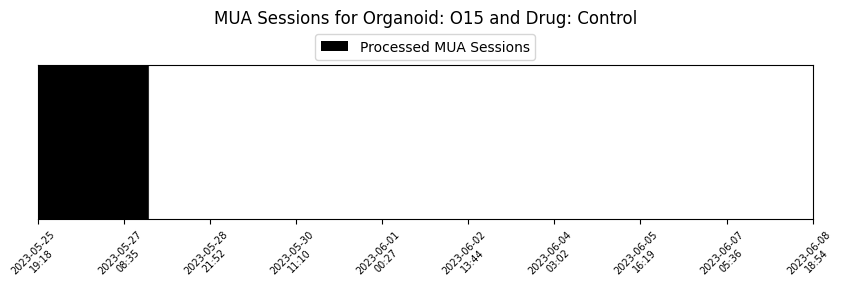

In [60]:
def downsample_to_length(x, n_new):

    """Downsample 1D array x to length n_new using linear interpolation."""
    new_idx = np.linspace(0, x.size - 1, n_new).astype(int)
    return x[new_idx]

# determine the experiment boundaries (based on exp_key)
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time")

# find the available files within the experiment boundaries
file_times = (ephys.EphysRawFile & exp_key & f"file_time >= '{experiment_start_time}' AND file_time < '{experiment_end_time}'").fetch("file_time")

# find the processed MUA sessions within the experiment boundaries
processed_file_times = (mua.MUAEphysSession & exp_key & f"start_time >= '{experiment_start_time}' AND start_time < '{experiment_end_time}'").fetch("start_time")

# create a visualization of the data already processed for the given exp_key
fig = plt.figure(figsize=(10, 2))
ax = fig.gca()

processed_bool = np.isin(file_times, processed_file_times)
ax.imshow(processed_bool[np.newaxis, :], aspect="auto", cmap="binary")

xticks = [d.strftime('%Y-%m-%d\n%H:%M') for d in downsample_to_length(file_times, 10)]
ax.set_xticks(np.linspace(0, len(file_times) - 1, 10))
ax.set_xticklabels(xticks, rotation=45, fontsize=7)
ax.set_yticks([])

ax.set_title(f"MUA Sessions for Organoid: {organoid_id} and Drug: {drug_name}", pad=30)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='black', label='Processed MUA Sessions')]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 2.1),
    borderaxespad=10,
)

plt.show()

#### **Step 4: Select Boundaries to Insert New MUA Sessions**

Based on the visualization above, select the start and end times for the new MUA sessions to be created. Ensure that these times fall within the experiment boundaries. Duplicated entries will be automatically ignored during insertion.

In [62]:
session_end_time = experiment_end_time
session_start_time = session_end_time - timedelta(days=2)

insert_file_times = file_times[(session_start_time <= file_times) & (file_times < session_end_time)]
print(f"Preparing to insert MUA sessions from {session_start_time} to {session_end_time} ({len(insert_file_times)} files)")

Preparing to insert MUA sessions from 2023-06-06 18:55:00 to 2023-06-08 18:55:00 (2880 files)


New Visualization Showing MUA Sessions to be Inserted

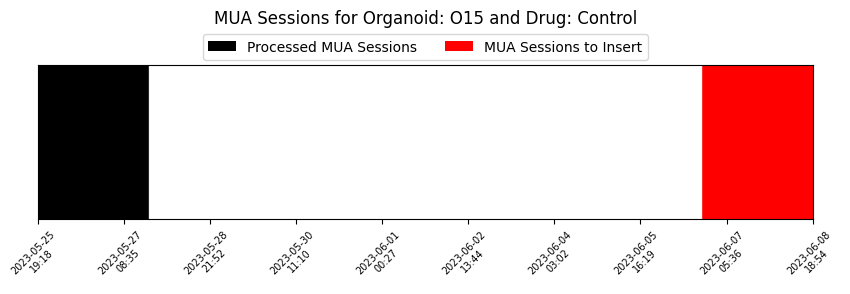

In [68]:
insert_bool = np.isin(file_times, insert_file_times)

# Create RGB visualization showing both processed and insert sessions
rgb_image = np.ones((1, len(file_times), 3))

# Red for sessions to be inserted
rgb_image[insert_bool[np.newaxis, :]] = [1, 0, 0]

# Black for already processed sessions (not being inserted)
rgb_image[processed_bool[np.newaxis, :] & ~insert_bool[np.newaxis, :]] = [0, 0, 0]

fig = plt.figure(figsize=(10, 2))
ax = fig.gca()
ax.imshow(rgb_image, aspect="auto")

xticks = [d.strftime('%Y-%m-%d\n%H:%M') for d in downsample_to_length(file_times, 10)]
ax.set_xticks(np.linspace(0, len(file_times) - 1, 10))
ax.set_xticklabels(xticks, rotation=45, fontsize=7)
ax.set_yticks([])

ax.set_title(f"MUA Sessions for Organoid: {organoid_id} and Drug: {drug_name}", pad=30)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', label='Processed MUA Sessions'),
    Patch(facecolor='red', label='MUA Sessions to Insert')
]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 2.1),
    borderaxespad=10,
    ncol=2,
)

plt.show()

#### **Step 5: Insert MUAEphysSessions based on previously defined Parameters**

In [ ]:
mua_key_list = [
    {
        **exp_key,
        "start_time": start_time,
    }
    for start_time in insert_file_times
]

mua.MUAEphysSession & mua_key_list

[2026-01-05 12:23:08,896][WARNING]: Reconnecting to MySQL server.


organoid_id e.g. O17,experiment_start_time,start_time,end_time,"port_id e.g. A, B, C, ..."


In [ ]:
mua.MUAEphysSession.populate(mua_key_list, skip_duplicates=True, allow_direct_insert=True)

MissingAttributeError: Field 'end_time' doesn't have a default value